<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/Model13_11F_reproducible_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ===============================
# Model 13 - 11 feature - reproducible
# ===============================

!pip install -q gdown

import gdown
gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE


# -------------------------------
# Reproducibility
# -------------------------------

def seed_everything(seed=42):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    np.random.seed(seed)
    random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.use_deterministic_algorithms(True, warn_only=True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


SEED = 42
seed_everything(SEED)


# -------------------------------
# Read Dataset
# -------------------------------

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(subset=["HPV Status"])


# -------------------------------
# Missing values
# -------------------------------

tobacco_mode = df["Tobacco Consumption"].mode()[0]
df["Tobacco Consumption"] = df["Tobacco Consumption"].fillna(tobacco_mode)

alcohol_mode = df["Alcohol Consumption"].mode()[0]
df["Alcohol Consumption"] = df["Alcohol Consumption"].fillna(alcohol_mode)


# -------------------------------
# Remove unwanted columns
# -------------------------------

df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(df.shape)


# -------------------------------
# Encode categorical variables
# -------------------------------

df["T-stage"] = df["T-stage"].replace({
    "T0":0,
    "T1":1,
    "T2":2,
    "T3":3,
    "T4":4
})

df["N-stage"] = df["N-stage"].replace({
    "N0":0,
    "N1":1,
    "N2":2,
    "N3":3
})

df["M-stage"] = df["M-stage"].replace({
    "M0":0,
    "M1":1
})


# -------------------------------
# Features
# -------------------------------

X = df[
    [
        "Age",
        "Gender",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "Relapse",
        "RFS",
        "Treatment",
        "T-stage",
        "N-stage",
        "M-stage"
    ]
]

y = df["HPV Status"]


# -------------------------------
# Train/Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Train samples:")
print(y_train.value_counts())

print("\nTest samples:")
print(y_test.value_counts())


# -------------------------------
# Standardisation
# -------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# SMOTE
# -------------------------------

smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# -------------------------------
# Torch tensors
# -------------------------------

X_train_smote = torch.FloatTensor(X_train_smote)
X_test = torch.FloatTensor(X_test)

y_train_smote = torch.LongTensor(
    y_train_smote.to_numpy()
)

y_test = torch.LongTensor(
    y_test.to_numpy()
)

# -------------------------------
# Model 13 Architecture
# -------------------------------

class HPVNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(11, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x


# -------------------------------
# Model
# -------------------------------

model = HPVNet()

weights = torch.tensor(
    [3.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# -------------------------------
# Training
# -------------------------------

epochs = 500

best_test_loss = float("inf")
best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_smote)

    train_loss = criterion(
        outputs,
        y_train_smote
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_loss = criterion(
            test_outputs,
            y_test
        )

    if test_loss.item() < best_test_loss:

        best_test_loss = test_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Test={test_loss.item():.4f}"
        )


print("\nBest Test Loss =", round(best_test_loss, 4))
print("Best Epoch =", best_epoch)


# -------------------------------
# Load Best Model
# -------------------------------

model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted = torch.argmax(
        outputs,
        dim=1
    )


# -------------------------------
# Classification Report
# -------------------------------

print("\nClassification Report\n")

print(

    classification_report(

        y_test.numpy(),

        predicted.numpy(),

        digits=4

    )

)


# -------------------------------
# Confusion Matrix
# -------------------------------

cm = confusion_matrix(

    y_test.numpy(),

    predicted.numpy()

)

print("Confusion Matrix")

print(cm)


# -------------------------------
# Metrics
# -------------------------------

bal_acc = balanced_accuracy_score(

    y_test.numpy(),

    predicted.numpy()

)

f1 = f1_score(

    y_test.numpy(),

    predicted.numpy()

)

y_prob = probabilities.numpy()

auc = roc_auc_score(

    y_test.numpy(),

    y_prob[:, 1]

)

print(f"\nBalanced Accuracy: {bal_acc:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

print("\nArchitecture: 11-64-32-16-2")
print("Optimiser: Adam")
print("Learning Rate: 0.001")
print("Class Weights: [3.0, 1.0]")
print("SMOTE: Yes")
print("Epochs: 500")

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 41.0MB/s]


(423, 12)
Train samples:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64

Test samples:
HPV Status
1.0    80
0.0     5
Name: count, dtype: int64

After SMOTE:
HPV Status
1.0    320
0.0    320
Name: count, dtype: int64


/tmp/ipykernel_5350/3288996674.py:107: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"] = df["T-stage"].replace({
/tmp/ipykernel_5350/3288996674.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"] = df["N-stage"].replace({
/tmp/ipykernel_5350/3288996674.py:122: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no

Epoch 50, Train=0.3058, Test=0.7014
Epoch 100, Train=0.1306, Test=0.5354
Epoch 150, Train=0.0799, Test=0.7138
Epoch 200, Train=0.0373, Test=0.9458
Epoch 250, Train=0.0157, Test=1.4378
Epoch 300, Train=0.0092, Test=1.8528
Epoch 350, Train=0.0062, Test=2.1835
Epoch 400, Train=0.0044, Test=2.4644
Epoch 450, Train=0.0033, Test=2.6865
Epoch 500, Train=0.0025, Test=2.8809

Best Test Loss = 0.5196
Best Epoch = 90

Classification Report

              precision    recall  f1-score   support

           0     0.1364    0.6000    0.2222         5
           1     0.9683    0.7625    0.8531        80

    accuracy                         0.7529        85
   macro avg     0.5523    0.6812    0.5377        85
weighted avg     0.9193    0.7529    0.8160        85

Confusion Matrix
[[ 3  2]
 [19 61]]

Balanced Accuracy: 0.6812
F1-score:          0.8531
AUC:               0.8675

Architecture: 11-64-32-16-2
Optimiser: Adam
Learning Rate: 0.001
Class Weights: [3.0, 1.0]
SMOTE: Yes
Epochs: 500


ModuleNotFoundError: No module named 'lime'


Prediction Probabilities

    Actual  Predicted  Probability HPV Negative  Probability HPV Positive
0      1.0        1.0                  0.294885                  0.705115
1      1.0        1.0                  0.002444                  0.997556
2      1.0        1.0                  0.032164                  0.967836
3      1.0        1.0                  0.033800                  0.966200
4      1.0        1.0                  0.006883                  0.993117
..     ...        ...                       ...                       ...
80     1.0        1.0                  0.033749                  0.966251
81     1.0        1.0                  0.083411                  0.916589
82     0.0        0.0                  0.959933                  0.040066
83     0.0        0.0                  0.948788                  0.051212
84     1.0        1.0                  0.000087                  0.999913

[85 rows x 4 columns]

Saved: LIME_Predictions.csv

LIME ANALYSIS COMPLETE
Patients 

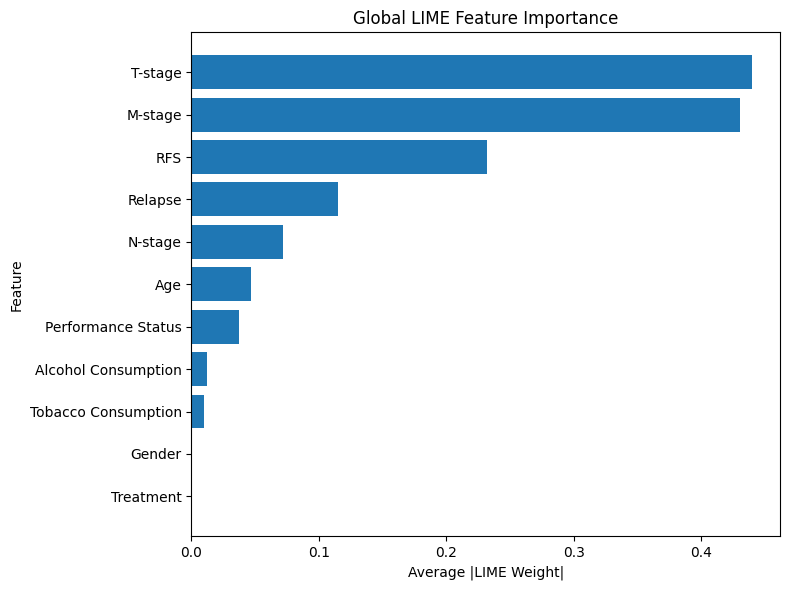


Saved:
Global_LIME_Importance.csv
Global_LIME_Importance.png


In [6]:
# ============================================================
# LIME FOR MODEL 13
# ============================================================

!pip install -q interpret lime

import numpy as np
import torch
import warnings

from interpret.blackbox import LimeTabular
from interpret import show

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Convert tensors to numpy
# ------------------------------------------------------------

X_train_np = X_train_smote.cpu().numpy()
X_test_np = X_test.cpu().numpy()

y_test_np = y_test.cpu().numpy()

# ------------------------------------------------------------
# Feature names
# ------------------------------------------------------------

feature_names = [
    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"
]

# ------------------------------------------------------------
# Prediction function for ANN
# ------------------------------------------------------------

def predict_proba(x):

    x = torch.FloatTensor(x)

    model.eval()

    with torch.no_grad():

        outputs = model(x)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

    return probabilities.numpy()

# ------------------------------------------------------------
# Create LIME explainer
# ------------------------------------------------------------

lime = LimeTabular(

    model=predict_proba,

    data=X_train_np,

    feature_names=feature_names,

    random_state=42

)

# ------------------------------------------------------------
# Explain ALL patients in the test set
# ------------------------------------------------------------

lime_local = lime.explain_local(

    X_test_np,

    y_test_np,

    name="Model13_LIME"

)

# ------------------------------------------------------------
# Display LIME dashboard
# ------------------------------------------------------------

show(lime_local)

# ------------------------------------------------------------
# Print prediction probabilities
# ------------------------------------------------------------

print("\nPrediction Probabilities\n")

probs = predict_proba(X_test_np)

prediction_df = np.column_stack(
    (
        y_test_np,
        np.argmax(probs, axis=1),
        probs[:,0],
        probs[:,1]
    )
)

import pandas as pd

prediction_df = pd.DataFrame(
    prediction_df,
    columns=[
        "Actual",
        "Predicted",
        "Probability HPV Negative",
        "Probability HPV Positive"
    ]
)

print(prediction_df)

prediction_df.to_csv(
    "LIME_Predictions.csv",
    index=False
)

print("\nSaved: LIME_Predictions.csv")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n===============================")
print("LIME ANALYSIS COMPLETE")
print("===============================")

print(f"Patients explained : {len(X_test_np)}")
print(f"Number of features : {len(feature_names)}")

print("\nModel Architecture")
print("11 -> 64 -> 32 -> 16 -> 2")

print("Optimiser : Adam")
print("Learning Rate : 0.001")
print("SMOTE : Yes")
print("Class Weights : [3.0, 1.0]")

print("\nThe interactive LIME dashboard should now be displayed above.")

print("\nYou can click on each patient to inspect")
print("which clinical variables contributed most")
print("towards the HPV prediction.")

print("\nAnalysis Complete.")

# ============================================================
# GLOBAL LIME FEATURE IMPORTANCE
# Average importance across ALL test patients
# ============================================================

from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Create standard LIME explainer
# ------------------------------------------------------------

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=["HPV Negative", "HPV Positive"],
    mode="classification",
    random_state=42
)

# ------------------------------------------------------------
# Calculate importance for every patient
# ------------------------------------------------------------

importance = np.zeros(len(feature_names))

for patient in X_test_np:

    explanation = explainer.explain_instance(
        patient,
        predict_proba,
        num_features=len(feature_names)
    )

    for feature, weight in explanation.as_list():

        for i, name in enumerate(feature_names):

            if name in feature:
                importance[i] += abs(weight)

# ------------------------------------------------------------
# Average importance
# ------------------------------------------------------------

importance = importance / len(X_test_np)

results = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute LIME Weight": importance
})

results = results.sort_values(
    "Mean Absolute LIME Weight",
    ascending=False
)

print("\nGLOBAL LIME FEATURE IMPORTANCE\n")
print(results)

results.to_csv(
    "Global_LIME_Importance.csv",
    index=False
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.barh(
    results["Feature"],
    results["Mean Absolute LIME Weight"]
)

plt.xlabel("Average |LIME Weight|")
plt.ylabel("Feature")
plt.title("Global LIME Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "Global_LIME_Importance.png",
    dpi=300
)

plt.show()

print("\nSaved:")
print("Global_LIME_Importance.csv")
print("Global_LIME_Importance.png")